# Angles
General def through dot product
$$A\cdot B= |A||B|\cos\theta$$
$$\cos \theta= \frac{A\cdot B} {|A||B|}$$
and its easy on grids cuz the dot product in cartestian coordinates is simply
$$A_xB_x+A_y+B_y$$
So
$$\cos \theta= \frac {A_xB_x+A_yB_y}{ \sqrt{A_x^2+A_y^2} \sqrt{B_x^2+B_y^2}} $$

In [1]:
from AIce.functions import torchRMSE,trainloader,testloader,redim,getRMSE
from torch import optim
from AIce.models import NNforAngles
import numpy as np
import torch
import matplotlib.pyplot as plt

from time import strftime

# [['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath','sin','cos', 'windnorm'],
#             ['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath','sin','cos'],
#             ['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath'],
#             ['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE'],
#             ['u_ERA5','v_ERA5','h_piomas','sic_CDR'],
#             ['u_ERA5','v_ERA5','h_piomas','sic_CDR', 'windnorm'],
#             ['u_ERA5','v_ERA5','h_piomas'],
#             ['u_ERA5','v_ERA5']]

In [ ]:
# TRAINING LOOP FOR THE ONE TIME RUN FOR EXAMPLE
#  device='cuda'

# inputlist=['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath','sin','cos', 'windnorm']
# lr =1e-3
# n_epoch=20
# data,_,dataloader,means,stds,maxes,labels=trainloader('../data/DRIFT_DATA_TRAIN.csv',256,inputlist,target='angle')
# data=data.loc[data['costheta'==0]]

# mlp256=NNforAngles(len(labels[1])).to(device)
# print('Total Epoch: ', n_epoch)
# print('Learning Rate: ', lr)
# print(labels)

# rlosses={}
# losses=[]
# rloss=0
# rcount=0

# optimizer = optim.Adam(mlp256.parameters(),lr=lr) # optimizers

# for epoch in range(n_epoch):
#     print('Starting Epoch ',epoch)
#     curpercent=0
#     rl=[]
#     for i,data in enumerate(dataloader):

#         # get the inputs and the target
#         truth,inputs= data[0].to(device),data[1].to(device)

#         # zero the gradients,
#         optimizer.zero_grad()

#         # Forward,
#         out=mlp256(inputs)


#         loss = torchRMSE(target=truth, outputs=out)
#         # Backward
#         loss.backward()
#         losses.append(loss.item())
#         # Optimize

#         optimizer.step()

#         rloss+= loss.item()
#         rcount +=1
#         #print where we at plus the loss
#         percent= round(i/len(dataloader)*100)
#         if percent != curpercent:
#         #    print(percent, 'loss: ', rloss/rcount)
#             curpercent=percent
#             rl.append(rloss/rcount)
#             rloss=0
#             rcount=0
#     rlosses[epoch]=rl
#     print('Epoch avg loss: ', np.mean(rl))

# saving_name=f'angle_without_stoppage_{len(labels[1])}inputs_{n_epoch}E_{lr}lr_{strftime("%d-%Hh_%Mm_%Ss")}'

# torch.save(mlp256.state_dict(), f'.//weights//{saving_name}.pt')

# with open(f'.//weights//{saving_name}.txt','w') as f:
#     f.write(f'Model: NNforAngle (on gpu)\n')
#     f.write(f'Weights: {saving_name}.pt\n')
#     f.write(f'Associated inputs: {inputlist}')

# fig,ax =plt.subplots()
# epochavg=[]

# for i in (rlosses):
#     x=np.arange(i*len(rlosses[0]),len(rlosses[0])+i*len(rlosses[0]))
#     ax.plot(x,rlosses[i])#,label=f'Epoch {i+1}, lr={lr[i]:.1e}')
#     avg=np.mean(rlosses[i])
#     epochavg.append(avg)
# xx=[i*len(rlosses[0]) for i in rlosses]
# ax.plot(xx,epochavg,'.-k')
# plt.savefig(f'.//outputs//loss_for_{saving_name}.png')
# plt.close('all')


allright angles
Sin and Cos added
Bathymetry (bath) normalized by maximum
x/y (x_EASE, y_EASE) normalized by maximum
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score
           angle
0       0.669591
1       0.997651
2       2.719585
3       0.079998
4       2.405274
...          ...
339151  0.156929
339152  0.134888
339153  0.547946
339154  1.444349
339155  0.273171

[339156 rows x 1 columns]


# Visualizing the turning angles in the datasets

static cases kept for training
dot and cross product of the wind kept in the pd.dataframe
allright angles
Sin and Cos added
Bathymetry (bath) normalized by maximum
x/y (x_EASE, y_EASE) normalized by maximum
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score
3.141592653589793


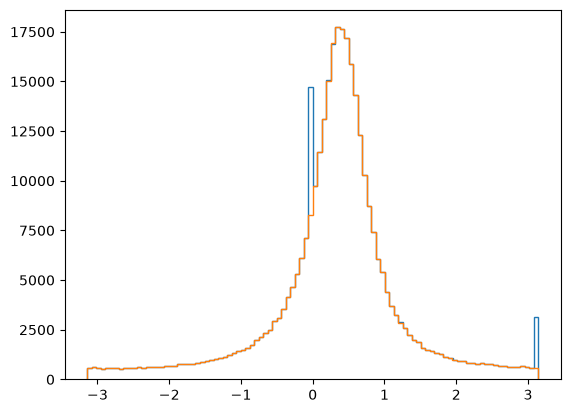

In [5]:
import matplotlib.pyplot as plt
inputlist=['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath','sin','cos', 'windnorm']

data,_,_,means,stds,maxes,_=trainloader('../data/DRIFT_DATA_TRAIN.csv',256,inputlist,target='angle'
                                    ,dotcross=True, no_static=False)

data=redim(data,
           means=means,
           stds=stds,
           maxes=maxes)

# plt.hist(data['cos'],100)
plt.show()
plt.hist((data['angle']),100, histtype='step')
plt.hist((data['angle'].loc[data['dot']!=0]), 100, histtype='step')
print(np.arccos(-1))

# Evaluating one model

Bath size is the full test set
static cases removed for testing
Sin and Cos added
Bathymetry (bath) normalized by maximum
x/y (x_EASE, y_EASE) normalized by maximum
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score
          angle      x_EASE      y_EASE    u_ERA5     v_ERA5   sic_CDR  \
0      1.024646  155.338104  135.642914  2.442403   1.127142  0.996916   
1      0.726512  137.390686  109.197037 -1.543713   7.514323  1.000000   
2      2.160783  143.100266  135.374527  1.953833   2.135191  0.995579   
3      0.712205  136.624252  124.138580 -4.295371  -1.320883  1.000000   
4      0.057347  125.033562  139.533203 -2.547196  -2.842972  0.608846   
...         ...         ...         ...       ...        ...       ...   
84784 -0.530254  199.609039  153.454193 -2.484974   4.338783  0.470374   
84785 -0.587750  100.408081  159.768951 -4.538159   4.005265  0.974692   
84786  0.404745  152.641693  161.907364 -3.090631   2.086311  1.000000   
84787  0.504549

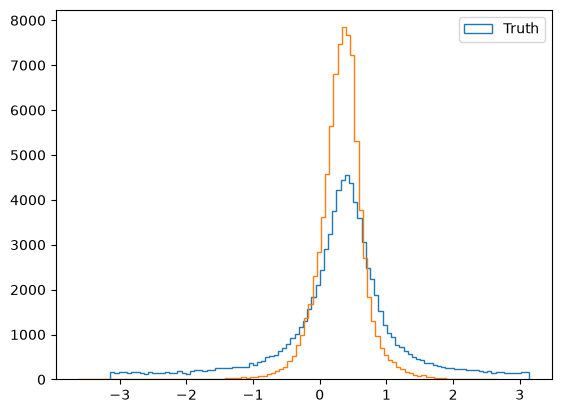

In [2]:
inputlist=['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath','sin','cos', 'windnorm']
testdata,_,_,means,stds,maxes,_=testloader('../data/DRIFT_DATA_TEST.csv',inputlist,'angle',
                                    trainingset_loaded=False, training_file='../data/DRIFT_DATA_TRAIN.csv',
                                    no_static=True, dotcross=False
                                    )# Get the means,stds,maxes using the longest list possible
anglemodel= NNforAngles(len(inputlist))
anglemodel.load_state_dict(torch.load('./weights/angle_without_stoppage_10inputs_20E_0.001lr_15-21h_32m_02s.pt', weights_only= True))
anglemodel.eval()

out=anglemodel(torch.tensor(testdata.drop(['angle'],axis=1).values, dtype= torch.float32)).detach().numpy()
testdata=redim(testdata,
               means=means,
               stds=stds,
               maxes=maxes)
testdata['output']=out
print(testdata)


plt.hist((testdata['angle']),100, histtype='step', label='Truth')
plt.hist((testdata['output']), 100, histtype='step')
plt.legend()


# Evaluating the 10 models for angles at once

In [2]:
#TO get the means stds maxes
t_bs=2
inputlist=['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath','sin','cos', 'windnorm']
testdata,_,_,means,stds,maxes,_=testloader('../data/DRIFT_DATA_TEST.csv',inputlist,'angle', bs=t_bs,
                                    trainingset_loaded=False, training_file='../data/DRIFT_DATA_TRAIN.csv',
                                    no_static=False, dotcross=True
                                    )# Get the means,stds,maxes using the longest list possible

inputstoweight={}

weightlist=[]
import os
for i in os.listdir('./weights'):
    """"Get the list of all the weights"""

    if i[-3:]=='.pt':
        if i[0]=='a':
            weightlist.append(i)


for k,weight in enumerate(weightlist):
    lst=[]
    
    with open(f'./weights/{weight[:-3]}.txt', 'r') as f:
        """Gets the inputlist associated with a particular Weight"""
        for i in range(2):
            f.readline()
        splits=f.read().split(':')
        lst=splits[1].strip()
        lst=lst.strip('[]').strip()
        lst=lst.split(',')
        lst=[x.strip()[1:-1] for x in lst]

    modeldata,_,_,_,_,_,_=testloader('../data/DRIFT_DATA_TEST.csv',inputlist=lst,target='angle', bs=t_bs,
                                     trainingset_loaded=True, means=means,stds=stds,maxes=maxes,
                                    no_static=False, dotcross=False)

    anglemodel= NNforAngles(len(lst))
    anglemodel.load_state_dict(torch.load(f'./weights/{weight}', weights_only= True))
    anglemodel.eval()

    out=anglemodel(torch.tensor(modeldata.drop(['angle'],axis=1).values, dtype= torch.float32)).detach().numpy()
    name=weight[22:25].strip('_') # I wanted a simpler name to differentiate them

    inputstoweight[name]=lst # saves the list of input into a dict
    # specificdf=data[lst] # gets the data for a specific inputlist

   
    testdata[name]=out # save the model prediction in the datapd with name associated to n_inputs

rmse={}

rmse={}

for i in inputstoweight.keys():
    rmse[i]=getRMSE(np.degrees(testdata['angle'].values), np.degrees(testdata[i].values))

print(rmse)

static cases kept for testing
dot and cross product of the wind kept in the pd.dataframe
Sin and Cos added
Bathymetry (bath) normalized by maximum
x/y (x_EASE, y_EASE) normalized by maximum
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score
static cases kept for testing
Wind components (u/v_ERA5) normalized by z-score
static cases kept for testing
Wind components (u/v_ERA5) normalized by z-score
static cases kept for testing
Sin and Cos added
Bathymetry (bath) normalized by maximum
x/y (x_EASE, y_EASE) normalized by maximum
Wind components (u/v_ERA5) normalized by z-score
static cases kept for testing
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score
static cases kept for testing
Sin and Cos added
Bathymetry (bath) normalized by maximum
x/y (x_EASE, y_EASE) normalized by maximum
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score
static cases kept for testing
Wind components (u/v_ERA5) normalized by 

In [1]:
import matplotlib as mpl
from matplotlib.colors import Normalize

print(testdata.columns)


###### THE HISTOGRAM
fig,ax =plt.subplots(dpi=200)
modellist=inputstoweight.keys()
norm=Normalize(0,len(modellist))
n_bins=360
cmap = mpl.colormaps['viridis']

ax.hist(np.degrees(testdata['angle']),n_bins, histtype='step', color='Grey', label='All Observations')

ax.hist(np.degrees(testdata['angle'].loc[testdata['dot']!=0]),n_bins, histtype='step', color='Black', label='Only moving Obs.')
print(inputstoweight)
for model in modellist:
    # print(model)
    # print(model[:2].strip('i'))
    number=int(model[:2].strip('i'))/10
    c=cmap(number)

    # if number*10 % 2 ==0:
    ax.hist(np.degrees(testdata[model]),n_bins, color=c, 
                histtype='step', alpha=.75,linewidth = 1 ,  label = int(number*10))
    #print(modelist[model])

ax.legend()
#plt.xlim([-np.pi,np.pi])
ax.set_xlim([-180,180])
ax.set_ylabel('Frequence bin=1$^\\circ$')
ax.set_xlabel('Angle $\\circ$')
ax.legend()
plt.show()

from AIce.plotting import PredAgainstTarget,ResidualOnTheMap

PredAgainstTarget(testdata['angle'].loc[testdata['dot']!=0],
                  testdata['10'].loc[testdata['dot']!=0],
                  testdata['windnorm'].loc[testdata['dot']!=0])

ResidualOnTheMap(testdata.loc[testdata['dot']!=0],'10','angle')


NameError: name 'testdata' is not defined